<a href="https://colab.research.google.com/github/1Kunalvats9/py-torch/blob/main/neural_network_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as f
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [91]:
#Creating model class that inherits nn.Module

class NeuralNetwork(nn.Module):
  # input layer ( 4 features) --> hidden layers1 ---> hidden layers2 ---> Output Layer

  def __init__(self, input_features=4, h1=8, h2=8, output_features=3):
    super().__init__()
    #setting up our layers:
    self.fc1 = nn.Linear(input_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, output_features)

  def forward(self, X):
    X = f.relu(self.fc1(X))
    X = f.relu(self.fc2(X))
    X = self.out(X)

    return X

In [93]:
torch.manual_seed(41)

model = NeuralNetwork()


##Loading Data

In [94]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
df = pd.read_csv(url)

In [95]:
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [96]:
df['variety'] = df['variety'].replace('Setosa', 0.0)
df['variety'] = df['variety'].replace('Versicolor', 1.0)
df['variety'] = df['variety'].replace('Virginica', 2.0)


df.head()

/tmp/ipykernel_577/3351515841.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['variety'] = df['variety'].replace('Virginica', 2.0)


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [97]:
#Splitting our data into training and testing sets

X = df.drop('variety', axis=1)
y = df['variety']


In [98]:
#converting into numpy values

X = X.values
y = y.values

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [100]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [103]:
#setting criterion of model to measure the error, how far off the predictions are fromm ::

criterion = nn.CrossEntropyLoss()
#choosing optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

#Training Model

In [104]:
epochs = 150
losses = []
for i in range(epochs):
  #Go forward and get predictions
  y_pred = model.forward(X_train)

  loss = criterion(y_pred, y_train) # checking the loss of our predicted from training data
  losses.append(loss.detach().numpy())

  #print every 10 epochs to see progression
  if i%10 ==0:
    print(f"Epoch: {i} and loss: {loss}")

  #Do some backpropagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()



Epoch: 0 and loss: 0.6706127524375916
Epoch: 10 and loss: 0.392023503780365
Epoch: 20 and loss: 0.2243547886610031
Epoch: 30 and loss: 0.12327676266431808
Epoch: 40 and loss: 0.07557088881731033
Epoch: 50 and loss: 0.054746612906455994
Epoch: 60 and loss: 0.04436744004487991
Epoch: 70 and loss: 0.03822650760412216
Epoch: 80 and loss: 0.03406654670834541
Epoch: 90 and loss: 0.030996888875961304
Epoch: 100 and loss: 0.02859663777053356
Epoch: 110 and loss: 0.026643341407179832
Epoch: 120 and loss: 0.025208499282598495
Epoch: 130 and loss: 0.023699317127466202
Epoch: 140 and loss: 0.02245650440454483


Text(0.5, 0, 'Epochs')

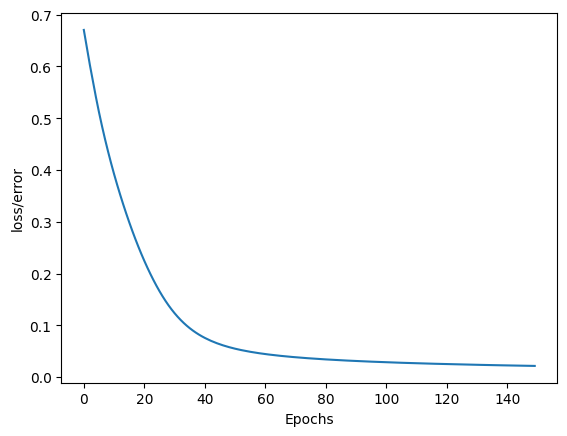

In [105]:
#Lets plot a graph

plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epochs")

#Evaluating Model on test data

In [106]:
with torch.no_grad():     #basically turns off back propogation
  y_eval = model.forward(X_test)

  loss = criterion(y_eval, y_test) # finding our evaluation error



In [107]:
loss

tensor(0.1629)

In [110]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "setosa"
    elif y_test[i] == 1:
      x = 'Versicolor'
    else:
      x = 'Virginica'


    print(f"{i + 1} {str(y_val)} \t {x}")

    #correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1
  print(f"we got {correct} correct")

1 tensor([-9.2078,  2.6098,  6.9116]) 	 Virginica
2 tensor([-12.6111,   0.9327,  12.6452]) 	 Virginica
3 tensor([-13.4797,   1.6774,  12.6824]) 	 Virginica
4 tensor([-4.8082,  5.5307, -1.4681]) 	 Versicolor
5 tensor([-11.2364,   2.2612,   9.5371]) 	 Virginica
6 tensor([-2.0862,  5.6663, -5.1349]) 	 Versicolor
7 tensor([-8.5202,  3.4494,  5.1428]) 	 Virginica
8 tensor([-4.5613,  5.5663, -1.8236]) 	 Versicolor
9 tensor([-9.8572,  2.8568,  7.3152]) 	 Virginica
10 tensor([-13.4337,   0.8849,  13.5965]) 	 Virginica
11 tensor([-8.1604,  3.5570,  4.6218]) 	 Virginica
12 tensor([ 13.4940,   6.1444, -25.9000]) 	 setosa
13 tensor([ 12.2465,   5.6015, -23.5369]) 	 setosa
14 tensor([-0.4450,  4.9363, -6.2508]) 	 Versicolor
15 tensor([ 11.5252,   5.9071, -22.8681]) 	 setosa
16 tensor([-7.7546,  3.9441,  3.7116]) 	 Virginica
17 tensor([ 12.2166,   5.7293, -23.6127]) 	 setosa
18 tensor([-8.9934,  2.8585,  6.3768]) 	 Versicolor
19 tensor([ 13.9149,   6.3223, -26.6936]) 	 setosa
20 tensor([ 10.9947,   

#Saving and Loading our model

In [111]:
torch.save(model.state_dict(), "iris_dataset_model")

In [112]:
#Load the saved model

new_model = NeuralNetwork()
new_model.load_state_dict(torch.load("iris_dataset_model"))

<All keys matched successfully>